In [1]:
#model hypothesis (objective)
def predict(x,m,b):
  return m*x+b;


In [2]:
#Cost Function (Mean Squared Error)
def mse(y,y_hat):
  n=len(y)
  return 1/n*((y-y_hat)**2).sum()

In [25]:
#Partial derivative with respect to m and b
def compute_gradients(x,y,y_hat):
  n=len(y)
  error=y-y_hat

  dm= -2/n * (x*error).sum()
  db= -2/n* (error).sum()

  return dm,db

In [26]:
#Gradient decent update rule
def update_parameters(m,b, dm,db, alpha):
  m=m-alpha*dm
  b=b-alpha*db

  return m,b


In [27]:
#Model Training
def train(x, y, alpha=0.001, iterations=1000):
    m, b = 0.0, 0.0
    loss_history = []

    for i in range(iterations):

        y_hat = predict(x, m, b)

        loss = mse(y, y_hat)
        loss_history.append(loss)

        dm, db = compute_gradients(x, y, y_hat)
        m, b = update_parameters(m, b, dm, db, alpha)

        # logging
        if i % 100 == 0:
            print(f"Iteration {i}, Loss: {loss:.4f}")

        # ⭐ Early stopping (NEW)
        if i > 0 and abs(loss_history[-1] - loss_history[-2]) < 1e-6:
            print("Early stopping triggered")
            break

    return m, b, loss_history

In [28]:
#Metrics
def mae(y, y_pred):
    return abs(y - y_pred).mean()

def rmse(y, y_pred):
    return ((y - y_pred) ** 2).mean() ** 0.5

def r2_score(y, y_pred):
    ss_total = ((y - y.mean())**2).sum()
    ss_res = ((y - y_pred)**2).sum()
    return 1 - (ss_res / ss_total)


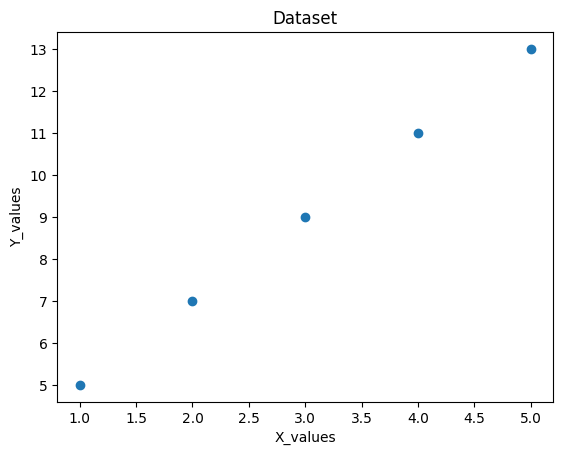

In [29]:
#loading the dataset

import numpy as np
import matplotlib.pyplot as plt

#equation is 2x+3
x=np.array([1,2,3,4,5],dtype=float)
y=np.array([5,7,9,11,13],dtype=float)

plt.scatter(x,y)

plt.xlabel("X_values")
plt.ylabel("Y_values")
plt.title("Dataset")
plt.show()




In [30]:
#train model (you already implemented train function above)

m, b, loss_history = train(x, y)

print("\nFinal Parameters:")
print("m =", m)
print("b =", b)


Iteration 0, Loss: 89.0000
Iteration 100, Loss: 1.6105
Iteration 200, Loss: 0.8266
Iteration 300, Loss: 0.7669
Iteration 400, Loss: 0.7167
Iteration 500, Loss: 0.6698
Iteration 600, Loss: 0.6260
Iteration 700, Loss: 0.5851
Iteration 800, Loss: 0.5468
Iteration 900, Loss: 0.5111

Final Parameters:
m = 2.448699722825159
b = 1.3800516285429847


In [34]:
#Predictions
y_pred=predict(x,m,b)

In [37]:
#Metrics Output
print("\nEvaluation Metrics:")
print("MAE:", mae(y, y_pred))
print("RMSE:", rmse(y, y_pred))
print("R2 Score:", r2_score(y, y_pred))


Evaluation Metrics:
MAE: 0.5932095079864985
RMSE: 0.6911268107231645
R2 Score: 0.9402929664374534


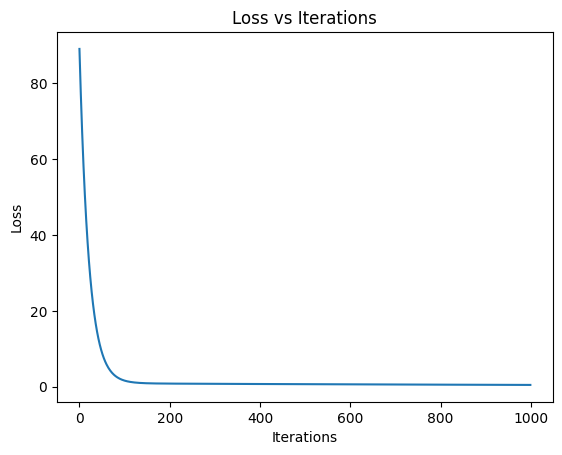

In [38]:
#Loss Curve

plt.figure()
plt.plot(loss_history)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


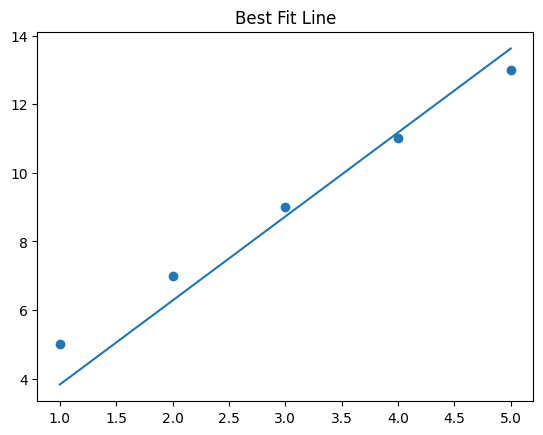

In [39]:
#Best Fit Line

plt.figure()
plt.scatter(x, y)
plt.plot(x, y_pred)
plt.title("Best Fit Line")
plt.show()

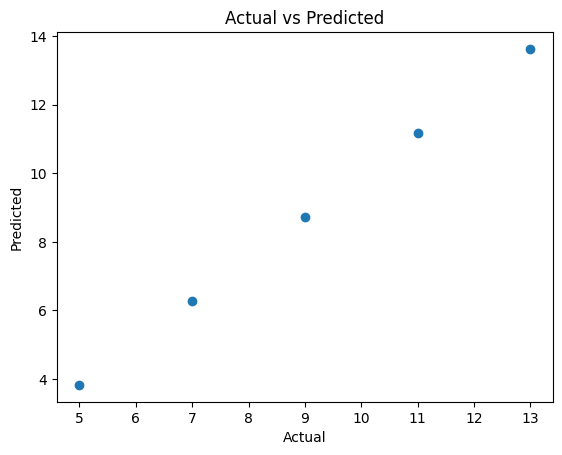

In [40]:
#Actual vs Predicted

plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [41]:
#Predict new value

x_new=int(input())
y_new_pred=predict(x_new,m,b)
print("Prediction of",x_new,":",y_new_pred)

8
Prediction of 8 : 20.969649411144253


In [43]:
#Use Sklearn Regression
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x.reshape(-1,1),y)

print("intercept:",model.intercept_)
print("Slope:",model.coef_[0])

intercept: 3.0
Slope: 2.0


In [44]:
model.predict(np.array(9).reshape(-1,1))

array([21.])